# <b>Previsão de cancelamento de contrato bancário</b>

Neste projeto serão utilizados modelos supervisionados de machine learning com o objetivo de estimar a probabilidade de um cliente cancelar seu contrato com o banco, fenômeno conhecido como churn. A variável resposta será representada de forma binária, em que o valor 1 indica que o cliente cancelou seu contrato e o valor 0 indica que o cliente permaneceu ativo na instituição bancária.

A previsão de churn é uma ferramenta estratégica para instituições financeiras, pois possibilita identificar clientes com maior risco de evasão e, consequentemente, auxilia na criação de ações voltadas à retenção de clientes.

Para o desenvolvimento deste projeto, será adotado o seguinte fluxo de etapas:

- Apresentação da problemática relacionada ao cancelamento de contratos bancários.
- Compreensão e análise das características do conjunto de dados fornecido pelo banco.
- Divisão dos dados em conjuntos de treino e teste.
- Realização da análise exploratória dos dados (EDA).
- Treinamento dos modelos de machine learning.
- Avaliação do desempenho dos modelos ajustados.
- Comparação dos resultados e escolha do modelo com melhor desempenho.

## <b>Problema de Negócio</b>

No setor bancário, a retenção de clientes representa um dos principais desafios estratégicos das instituições financeiras. O aumento da competitividade entre bancos tradicionais e bancos digitais ampliou as opções disponíveis para os consumidores, tornando o cancelamento de contratos (churn) um problema cada vez mais relevante. Nesse contexto, compreender os fatores que levam um cliente a encerrar seu relacionamento com o banco é fundamental para reduzir perdas financeiras e aumentar a fidelização.

A perda de clientes impacta diretamente indicadores importantes do negócio:

- O Custo de Aquisição de Clientes representa o valor investido pela instituição para conquistar novos clientes, incluindo despesas com marketing, vendas e campanhas de captação. Quando um cliente cancela seu contrato, parte desse investimento pode não gerar o retorno esperado, aumentando os custos operacionais da empresa.

- Já o Valor Vitalício do Cliente corresponde ao valor financeiro que um cliente pode gerar para o banco ao longo de todo o seu relacionamento com a instituição. Clientes com maior tempo de permanência tendem a consumir mais produtos e serviços financeiros, como cartões de crédito, empréstimos, seguros e investimentos. Dessa forma, reduzir a evasão de clientes contribui diretamente para o aumento valor vitalício do cliente. 

- Outro indicador fundamental é a Taxa de Cancelamento, que mede a proporção de clientes que encerraram seu vínculo com o banco em determinado período. Taxas elevadas dessa métrica podem indicar problemas relacionados à satisfação dos clientes, qualidade dos serviços, concorrência ou estratégias de relacionamento. 

Diante desse cenário, técnicas de machine learning podem auxiliar na identificação de padrões associados ao cancelamento de contratos, permitindo que o banco antecipe comportamentos de evasão e desenvolva ações preventivas para retenção de clientes.

### <b>Objetivos do Projeto</b>

O presente projeto possui como objetivo principal desenvolver modelos supervisionados de machine learning capazes de prever a probabilidade de cancelamento de clientes bancários com base em características presentes no conjunto de dados.

Entre os objetivos específicos do projeto, destacam-se:

- Identificar os principais fatores relacionados ao cancelamento de clientes.
- Realizar análises exploratórias para compreender o comportamento dos dados.
- Construir e treinar modelos preditivos para classificação de clientes.
- Avaliar o desempenho dos modelos utilizando métricas apropriadas.
- Comparar os resultados obtidos entre os modelos desenvolvidos.
- Auxiliar na geração de insights estratégicos para retenção de clientes e redução da taxa de churn.

A aplicação de modelos preditivos de churn permite ao banco identificar clientes com maior probabilidade de cancelamento, possibilitando ações preventivas de retenção. Com isso, a instituição pode reduzir perdas financeiras, aumentar a fidelização dos clientes e otimizar investimentos relacionados ao custo de aquisição de clientes. Além disso, a redução da evasão contribui diretamente para o aumento do valor vitalício do cliente e para a melhoria da eficiência estratégica do negócio.

### <b>Importanto as bibliotecas utilizadas no projeto</b>

In [31]:
#Importa o Pandas, usada para ler, manipular e analisar dados em formato de tabela.
import pandas as pd

#Importa o NumPy, essencial para cálculos matemáticos rápidos.
import numpy as np

#Importam o Matplotlib, que é a biblioteca base para gerar gráficos.
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches

#Importa o Seaborn, que facilita a criação de gráficos estatísticos mais completos com menos código.
import seaborn as sns

#Importa a função train_test_split do módulo model_selection do scikit-learn, usada para dividir os dados em conjuntos de treinamento e teste.
from sklearn.model_selection import train_test_split

## <b>Explorando os dados</b>
- O conjunto de dados utilizado neste projeto foi obtido através da plataforma Kaggle: https://www.kaggle.com/datasets/radheshyamkollipara/bank-customer-churn/data

Na sequência, será realizado o carregamento da base de dados.

In [5]:
data_path = '../input/Customer-Churn-Records.csv'
df = pd.read_csv(data_path)

A função df.head(10) exibe as 10 primeiras observações das variáveis presentes no conjunto de dados.

In [6]:
df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1,1,5,DIAMOND,484
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0,0,2,SILVER,206
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1,1,2,DIAMOND,282
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0,0,3,GOLD,251
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0,0,3,GOLD,342


### <b>Dicionário dos dados</b>

<b>RowNumber: </b> Corresponde ao número do registro. Variável quantitativa discreta.<br>
<b>CustomerId: </b> Representa o código de registro do cliente. Variável quantitativa discreta.<br>
<b>Surname: </b> O sobrenome do cliente. Variável categórica nominal.<br>
<b>CreditScore: </b> O escore do cartão de cédito do cliente. Variável quantitativa discreta.<br>
<b>Geography: </b> A localização do cliente. Variável categórica nominal.<br>
<b>Gender: </b> O gênero do cliente. Variável categórica nominal.<br>
<b>Age: </b> Idade do cliente. Variável quantitativa discreta. <br>
<b>Tenure: </b> Número de anos em que o cliente permanece no banco. Variável quantitativa discreta. <br>
<b>Balance: </b> Saldo bancário do cliente. Variável quantitativa contínua.<br>
<b>NumOfProducts: </b> Quantidade de produtos bancários adquiridos pelo cliente. Variável quantitativa discreta. <br>
<b>HasCrCard: </b> Indica se o cliente possui cartão de crédito. 1 = Sim e 0 = Não. Variável categórica binária. <br>
<b>IsActiveMember: </b> Indica se o cliente é um membro ativo. 1 = Sim e 0 = Não. Variável categórica binária. <br>
<b>EstimatedSalary: </b> Salário estimado do cliente. Variável quantitativa contínua. <br>
<b>Exited: </b> Indica se o cliente deixou o banco. 1 = Saiu e 0 = Permaneceu. Variável alvo do conjunto de dados. Variável categórica binária.<br>
<b>Complain: </b> Indica se o cliente realizou alguma reclamação. 1 = Sim e 0 = Não. Variável categórica binária<br>
<b>Satisfaction Score: </b> Nota de satisfação dada pelo cliente após resolução da reclamação. Variável categórica ordinal. <br>
<b>Card Type: </b> tipo de cartão que o cliente possui. Variável categórica ordinal. <br>
<b>Points Earned: </b> pontos acumulados pelo cliente pelo uso do cartão de crédito. Variável quantitativa discreta.<br>

### <b>Informações derais do conjunto de dados</b>

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

O conjunto de dados possui 10.000 registros distribuídos em 18 variáveis, indicando uma base relativamente robusta para aplicação de modelos supervisionados de machine learning. Observa-se que todas as colunas apresentam 10.000 valores não nulos, o que indica ausência de dados faltantes. 
Em relação aos tipos de dados, o conjunto apresenta:

- 12 variáveis do tipo int64, correspondendo principalmente a variáveis quantitativas discretas e variáveis binárias.
- 2 variáveis do tipo float64, representando variáveis quantitativas contínuas.
- 4 variáveis do tipo object, associadas às variáveis categóricas textuais.

Realizaremos a remoção das colunas <b>RowNumber</b>, <b>CustomerId</b> e <b>Surname</b> do conjunto de dados original. Essas variáveis foram excluídas por possuírem caráter apenas identificador, não contribuindo diretamente para o processo de previsão do churn dos clientes.

In [8]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

Foi realizada uma padronização das variáveis do conjunto de dados, transformando os nomes das colunas em formato minúsculo para facilitar a manipulação e análise dos dados.

In [9]:
df.columns = [x.lower() for x in df.columns]

A variável categórica gender foi convertida em valores numéricos, atribuindo 1 para clientes do sexo masculino e 0 para clientes do sexo feminino para facilitar a aplicação dos modelos de aprendizado de máquina.

In [10]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
creditscore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
gender,10000.0,0.545700,0.497932,0.00,0.00,1.000,1.0000,1.00
age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
numofproducts,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
hascrcard,10000.0,0.705500,0.455840,0.00,0.00,1.000,1.0000,1.00
isactivemember,10000.0,0.515100,0.499797,0.00,0.00,1.000,1.0000,1.00
estimatedsalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
exited,10000.0,0.203800,0.402842,0.00,0.00,0.000,0.0000,1.00


### <b>Análise descritiva</b>

- O escore de crédito médio é de aproximadamente 651 pontos. Os valores variam entre 350 e 850, indicando grande heterogeneidade financeira entre os clientes.
- A idade média dos clientes é de aproximadamente 39 anos e o intervalo entre 32 a 44 anos contem a maior parte dos clientes.
- O tempo médio de relacionamento com o banco é de aproximadamente 5 anos.
- O saldo médio é de aproximadamente 76 mil. O saldo máximo ultrapassa 250 mil, indicando possíveis outliers financeiros.
- A maioria dos clientes possui entre 1 e 2 produtos. A média é aproximadamente 1,53, indicando baixa diversificação de serviços bancários.
- O salário estimado apresenta média próxima de 100 mil. A mediana próxima da média sugere distribuição relativamente simétrica.
- Aproximadamente 54,6% dos clientes são do sexo masculino.
- Cerca de 70,5% dos clientes possuem cartão de crédito.
- Aproximadamente 51,5% dos clientes são considerados membros ativos.
- Aproximadamente 20,4% dos clientes registraram reclamações.
- A pontuação média de satisfação é de aproximadamente 3,01 em uma escala de 1 a 5. A mediana igual a 3 sugere satisfação moderada da maior parte dos clientes.
- Os clientes possuem média de aproximadamente 606 pontos acumulados.

In [18]:
df.isna().sum()

creditscore           0
geography             0
gender                0
age                   0
tenure                0
balance               0
numofproducts         0
hascrcard             0
isactivemember        0
estimatedsalary       0
exited                0
complain              0
satisfaction score    0
card type             0
point earned          0
dtype: int64

Os resultados indicam que nenhuma das variáveis do conjunto de dados possui valores nulos. Dessa forma, não foi necessário aplicar técnicas de tratamento de dados ausentes, como imputação ou remoção de registros.

### <b>Separando os dados em treino e teste</b>
A estratégia de divisão dos dados prioriza a neutralidade do modelo. Ao realizar a EDA apenas nos dados de treino, simulamos com precisão o desempenho do modelo em dados desconhecidos. Aplicamos a estratificação stratify=y para mitigar o impacto do desbalanceamento de classes Churn vs. Ativos, garantindo que os subconjuntos de dados mantenham a representatividade estatística do dataset original.

In [19]:
X = df.drop(columns=['exited'])
y = df['exited'].copy()

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [13]:
print(f'Proporção alvo de treinamento: ')
print(f'{y_treino.value_counts(normalize=True).mul(100).map("{:.2f}%".format)}')

print(f'Proporção alvo de teste: ')
print(f'{y_teste.value_counts(normalize=True).mul(100).map("{:.2f}%".format)}')

Proporção alvo de treinamento: 
exited
0    79.62%
1    20.38%
Name: proportion, dtype: object
Proporção alvo de teste: 
exited
0    79.60%
1    20.40%
Name: proportion, dtype: object


O conjunto de treinamento apresentou aproximadamente 79,62% de clientes não evasores e 20,38% de evasores, enquanto o conjunto de teste apresentou 79,60% e 20,40%, respectivamente. Isso demonstra que o processo de separação dos dados manteve o balanceamento original da variável resposta, favorecendo uma avaliação mais confiável dos modelos de Machine Learning.

A função pd.concat() foi utilizada para combinar as variáveis independentes e a variável alvo em um único DataFrame de treinamento. com o objetivo de realizar a análise exploratória dos dados.

In [14]:
treino = pd.concat([X_treino, y_treino], axis=1)

treino.head(10)

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,complain,satisfaction score,card type,point earned,exited
4791,709,Spain,1,35,2,0.00,2,1,0,104982.39,0,2,GOLD,422,0
8881,744,France,1,29,1,43504.42,1,1,1,119327.75,0,1,PLATINUM,607,0
6166,773,France,1,64,2,145578.28,1,0,1,186172.85,0,1,SILVER,630,0
4473,646,Germany,0,29,4,105957.44,1,1,0,15470.91,0,1,PLATINUM,345,0
854,675,France,0,57,8,0.00,2,0,1,95463.29,0,3,SILVER,632,0
3697,745,Germany,1,48,10,96048.55,1,1,0,74510.65,0,1,PLATINUM,701,0
4332,507,Germany,1,31,2,134237.07,1,1,1,166423.66,1,3,PLATINUM,481,1
4287,714,Germany,1,53,1,99141.86,1,1,1,72496.05,1,3,PLATINUM,1000,1
5452,558,France,0,45,1,153697.53,2,0,0,89891.40,1,2,SILVER,351,1
8824,643,Spain,0,35,6,0.00,2,1,1,41549.64,0,1,PLATINUM,704,0


Observa-se que 20,38% dos clientes da base encerraram seus contratos, enquanto a grande maioria  79,62% permaneceu ativa. Assim tornasse nescessário alocar pesos distintos às classes, dessa forma aumentando a penalização para erros cometidos na classificação da classe menos numerozas. Com isso o modelo passa a dar maior importância à identificação desses clientes.

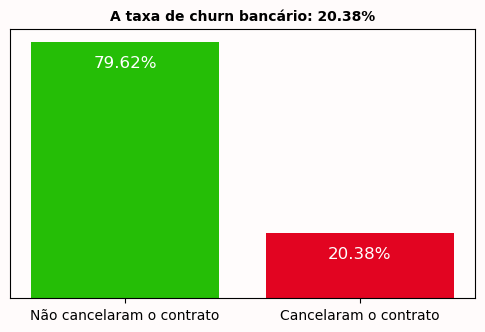

In [20]:
churn = df['exited'].value_counts(normalize=True).sort_index() * 100
labels = ['Não cancelaram o contrato', 'Cancelaram o contrato']
valores = [churn[0], churn[1]]
cores = ["#25BE06", "#E20421"]
plt.figure(figsize=(6,3.5), facecolor="#FFFBFB")
plt.grid(False)
plt.yticks([])
plt.xticks(fontsize=10)
bara = plt.bar(labels, valores, color=cores, width=0.8)
plt.title(
    f'A taxa de churn bancário: {valores[1]:.2f}%',
    fontsize=10,
    fontweight='bold',
    loc='center'
)

for bar, valor in zip(bara, valores):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        valor - 9,
        f'{valor:.2f}%',
        ha='center',
        va='bottom',
        color='white',
        fontsize=12
    )

plt.gca().set_facecolor("#FFFCFC")
plt.show()

A análise do perfil dos clientes revela que a base é fortemente concentrada na França 50,04%, com o restante dividido de forma equilibrada entre Alemanha 25,12% e Espanha 24,84%, tornando o mercado francês o principal direcionador do impacto financeiro do churn e possível alvo de campanhas futuras da empresa. Em contraste, os tipos de cartão de crédito Gold, Platinum, Silver e Diamond apresentam uma distribuição perfeitamente uniforme aproximadamente 25% para cada, uma característica atípica em cenários reais que sugere um baixo poder preditivo para essa variável.

In [21]:
print((treino['geography'].value_counts(normalize=True) * 100).map('{:.2f}%'.format))
print(f"\n{(treino['card type'].value_counts(normalize=True) * 100).map('{:.2f}%'.format)}")

geography
France     50.04%
Germany    25.12%
Spain      24.84%
Name: proportion, dtype: object

card type
GOLD        25.47%
PLATINUM    24.96%
SILVER      24.82%
DIAMOND     24.74%
Name: proportion, dtype: object


In [22]:
# Lista das variáveis numéricas
va_num = ['creditscore', 'age', 'tenure', 'balance', 'numofproducts', 'estimatedsalary', 'point earned']

# Lista das variáveis categóricas
va_cat = ['geography', 'gender', 'hascrcard', 'isactivemember', 'complain', 'satisfaction score', 'card type']

### <b> Detecção de outliers na base de dados</b>

A detecção de outliers via Intervalo Interquartil (IQR) revelou uma base de dados altamente consistente, com anomalias concentradas quase exclusivamente na idade age, 3,59%, o que no contexto bancário geralmente reflete um nicho real de clientes idosos e não erros. As demais variações foram irrelevantes ou nulas nas outras variáveis numéricas.

In [23]:
resultado = []

for coluna in va_num:
    
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[coluna] < limite_inferior) |
        (df[coluna] > limite_superior)
    ]
    
    qtd_outliers = outliers.shape[0]
    
    percentual = (qtd_outliers / df.shape[0]) * 100
    
    resultado.append({
        'Variável': coluna,
        'Qtd_Outliers': qtd_outliers,
        'Percentual (%)': round(percentual, 3)
    })

resultado = pd.DataFrame(resultado)
resultado

,Variável,Qtd_Outliers,Percentual (%)
0,creditscore,15,0.15
1,age,359,3.59
2,tenure,0,0.00
3,balance,0,0.00
4,numofproducts,60,0.60
5,estimatedsalary,0,0.00
6,point earned,0,0.00


### <b> Boxplot das variáveis numéricas</b>

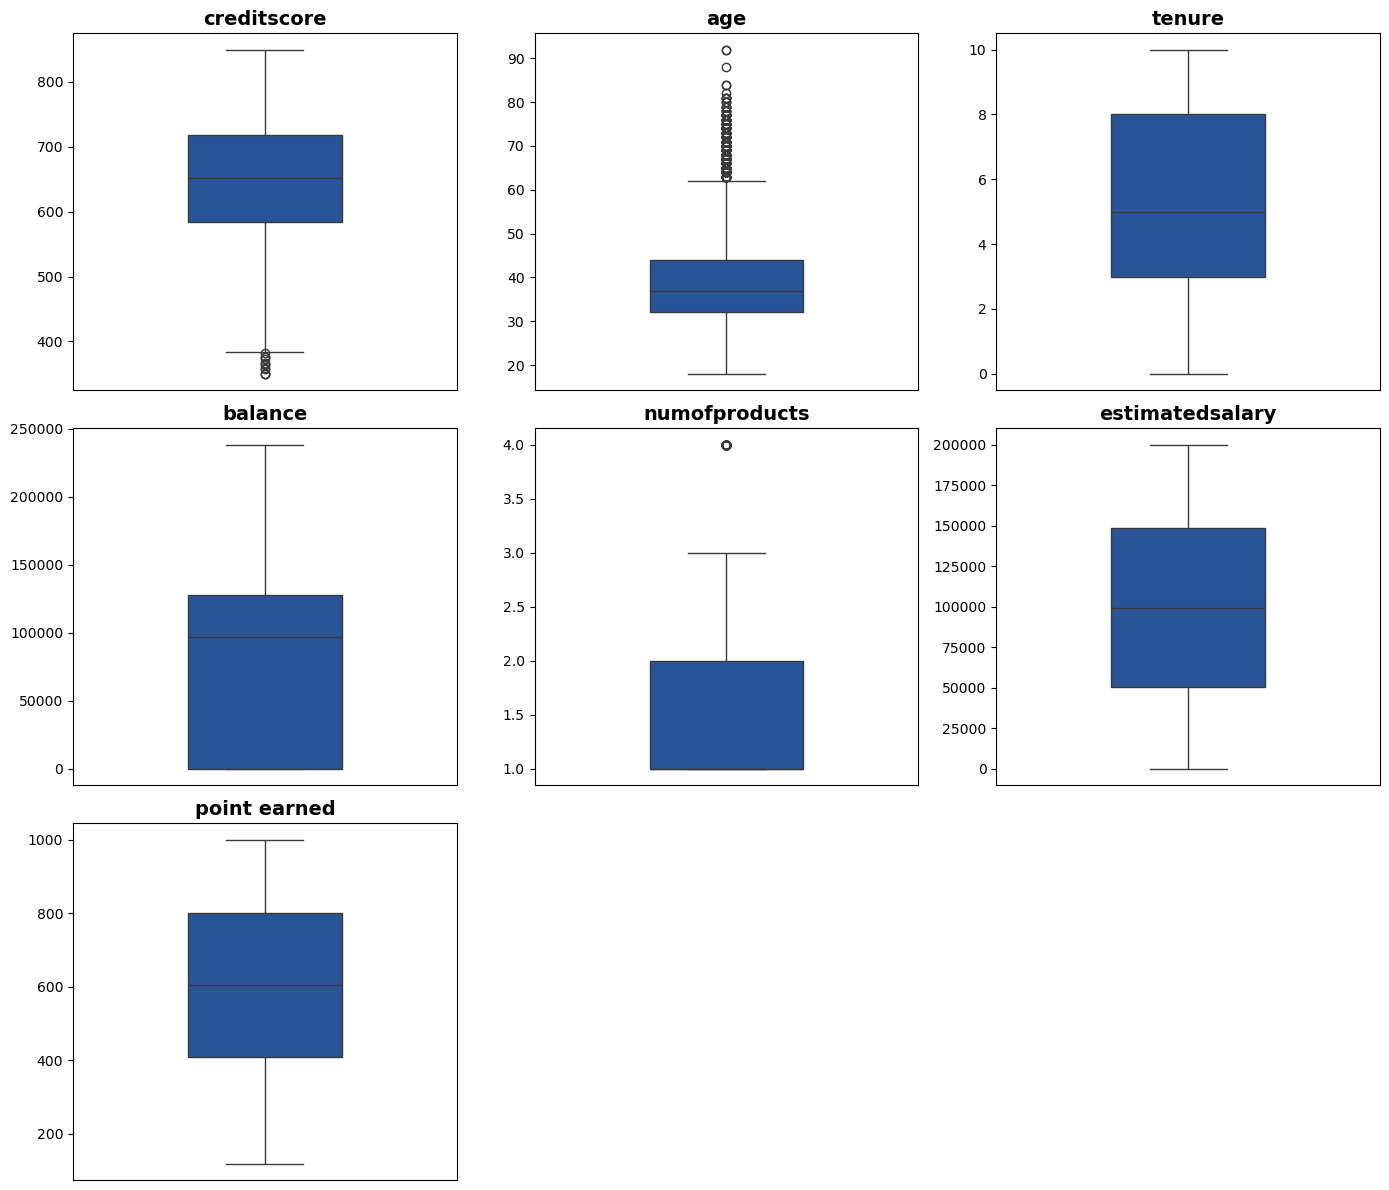

In [24]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(14, 12))

axes = axes.flatten()

for i, var in enumerate(va_num):

    sns.boxplot(
        y=treino[var],
        ax=axes[i],
        color="#1652aaff",
        width=0.4
    )

    axes[i].set_title(
        var,
        fontsize=14,
        fontweight='bold'
    )

    axes[i].set_ylabel('')

    axes[i].set_xticks([])

for j in range(len(va_num), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.show()

A visualização por boxplots corrobora os cálculos anteriores, ilustrando de forma clara a concentração de outliers na cauda superior da variável **age** e a presença isolada de anomalias pontuais em **numofproducts** e **creditscore**. O perfil central revelado aponta para um cliente com idade mediana em torno de 37 anos, score de crédito de 650 pontos e forte adesão a 1 ou 2 produtos da instituição. Chama a atenção a simetria quase perfeita e a ausência de discrepâncias em **tenure**, **estimatedsalary** e **point earned**, indicando distribuições muito uniformes que, assim como o tipo de cartão, precisarão ser avaliadas quanto ao seu real poder preditivo para o churn.

### <b> Gráficos de barras das variáveis categóricas</b>

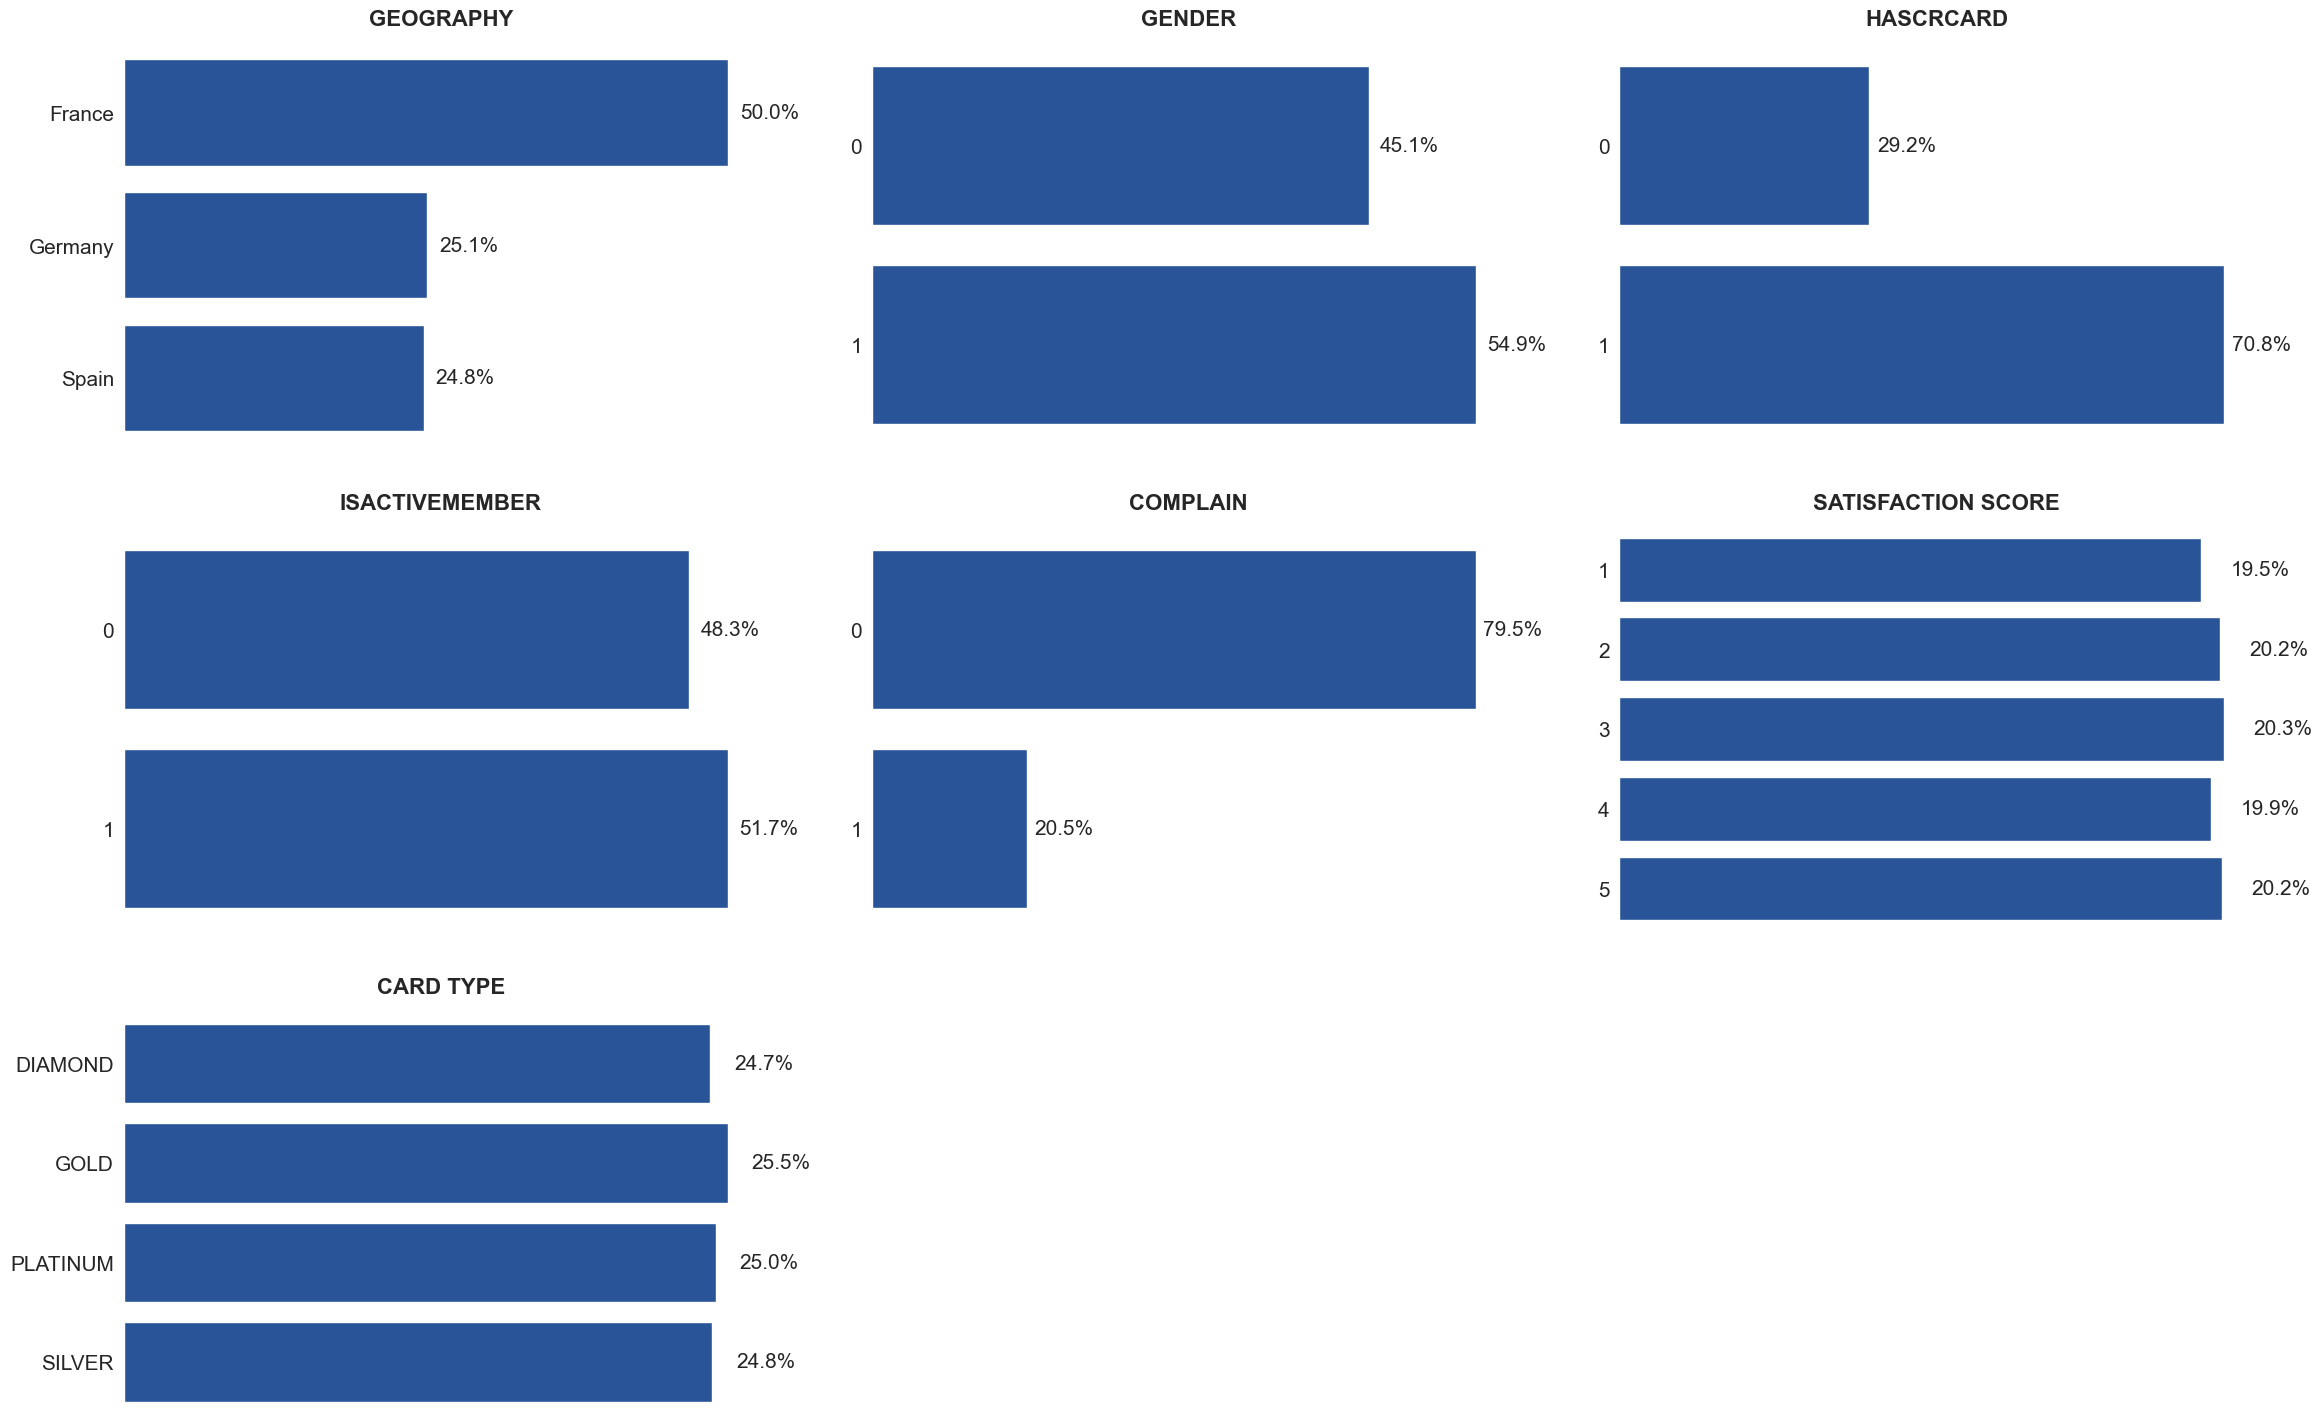

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(24, 15))
axes = axes.flatten() 

for i, var in enumerate(va_cat):
    proporcoes = treino[var].value_counts(normalize=True).sort_index() * 100

    rotulos_y = proporcoes.index.astype(str)

    sns.barplot(x=proporcoes.values, y=rotulos_y, ax=axes[i], color="#1652aaff")

    axes[i].set_title(var.upper(), fontsize=16, fontweight='bold', pad=15)

    axes[i].tick_params(axis='y', labelsize=15)

    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

    axes[i].set_xticks([])

    sns.despine(ax=axes[i], left=True, bottom=True)

    for p in axes[i].patches:
        width = p.get_width()

        axes[i].text(width + 1, 
                     p.get_y() + p.get_height() / 2, 
                     f'{width:.1f}%', 
                     ha='left', 
                     va='center', 
                     fontsize=15)

for j in range(len(va_cat), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=3.5)

plt.show()

O mapeamento das variáveis categóricas revela uma base com alta adesão a cartões de crédito 70,8% e engajamento equilibrado 51,7% de membros ativos. Do ponto de vista analítico, destacam-se duas grandes descobertas: primeiro, a variável **satisfaction score** possui uma distribuição perfeitamente uniforme aproximadamente 20% por nota, o que sugere baixo potencial preditivo e pouca utilidade prática, segundo, a variável **complain** aponta que 20,5% da base registrou queixas, uma proporção semelhante à taxa de evasão da empresa 20,38%. Essa correlação quase perfeita indica que o registro de reclamações pode ser o fator determinante mais forte para o churn.

### <b> Histograma das variáveis numéricas</b>

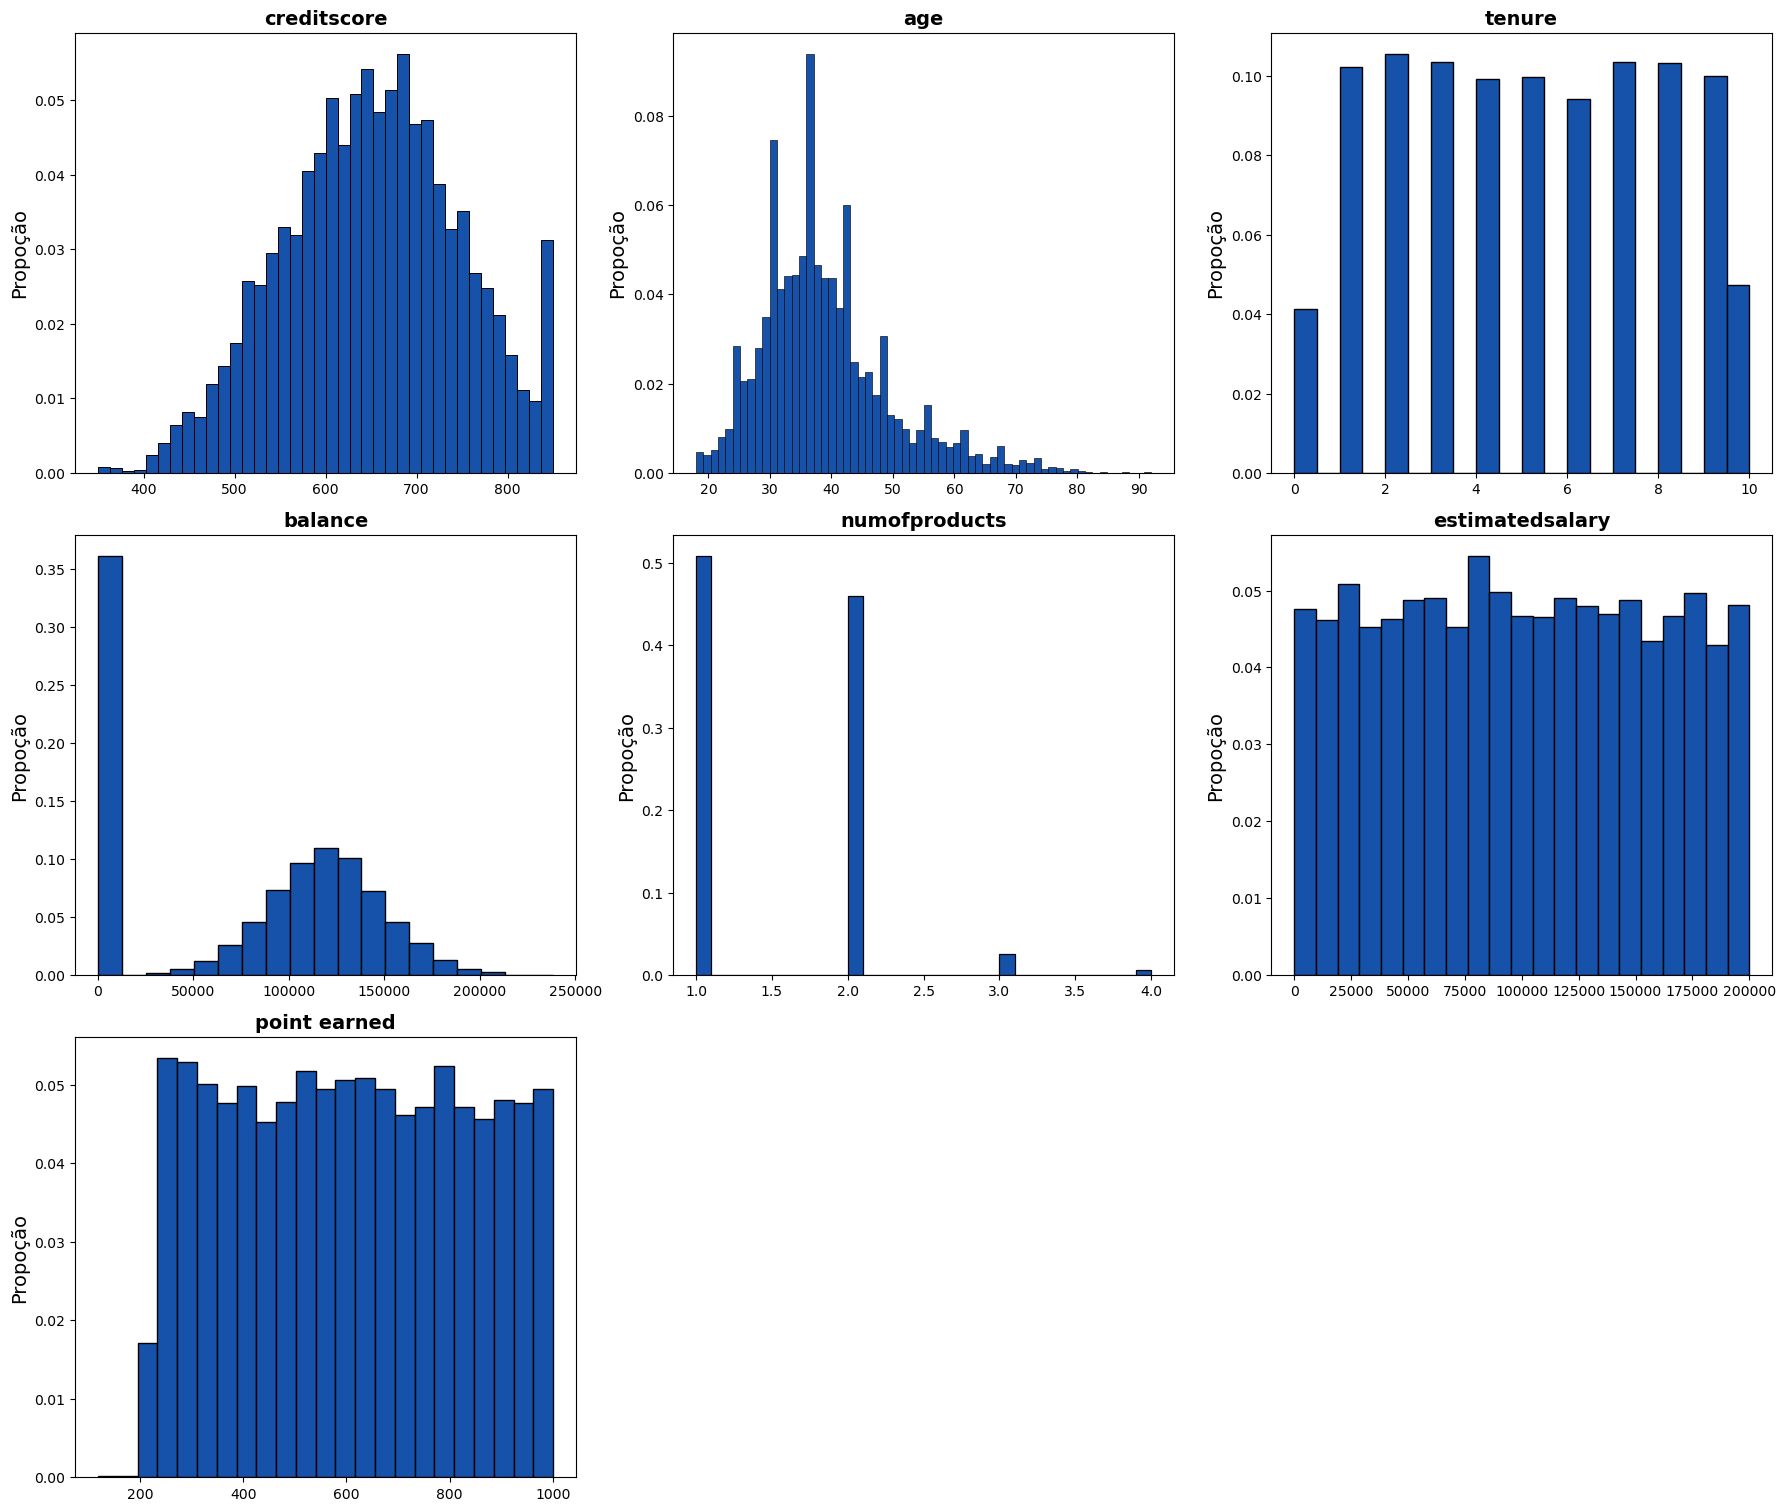

In [26]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 20)) 
axes = axes.flatten()

for i, col in enumerate(va_num):
    sns.histplot(data=treino, x=col, kde=False, stat="proportion", alpha=1, color="#1652aaff", ax=axes[i])
    
    axes[i].set_title(col, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Propoção', fontsize=14)

# Remove gráficos vazios
for j in range(len(va_num), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

A análise das distribuições via histogramas complementa o diagnóstico numérico revelando padrões estruturais cruciais na base. O achado mais crítico é a distribuição inflada de zeros na variável **balance**, apontando que cerca de 35% da carteira não possui fundos depositados, um indício forte de inatividade ou risco de evasão. A idade **age** confirma sua assimetria à direita, representando o público jovem-adulto dominante e a cauda de outliers idosos. Em contrapartida, as variáveis **estimatedsalary**, **point earned** e **tenure** exibem distribuições retangulares perfeitamente uniformes, o que sugere um baixo poder de separação de classes e levanta dúvidas sobre a importância preditiva dessas features para o modelo final.

## <b>Análise Bivariáda e Multivariada</b>

### <b> Histograma das variáveis numéricas levando em consideração a variável exited</b>

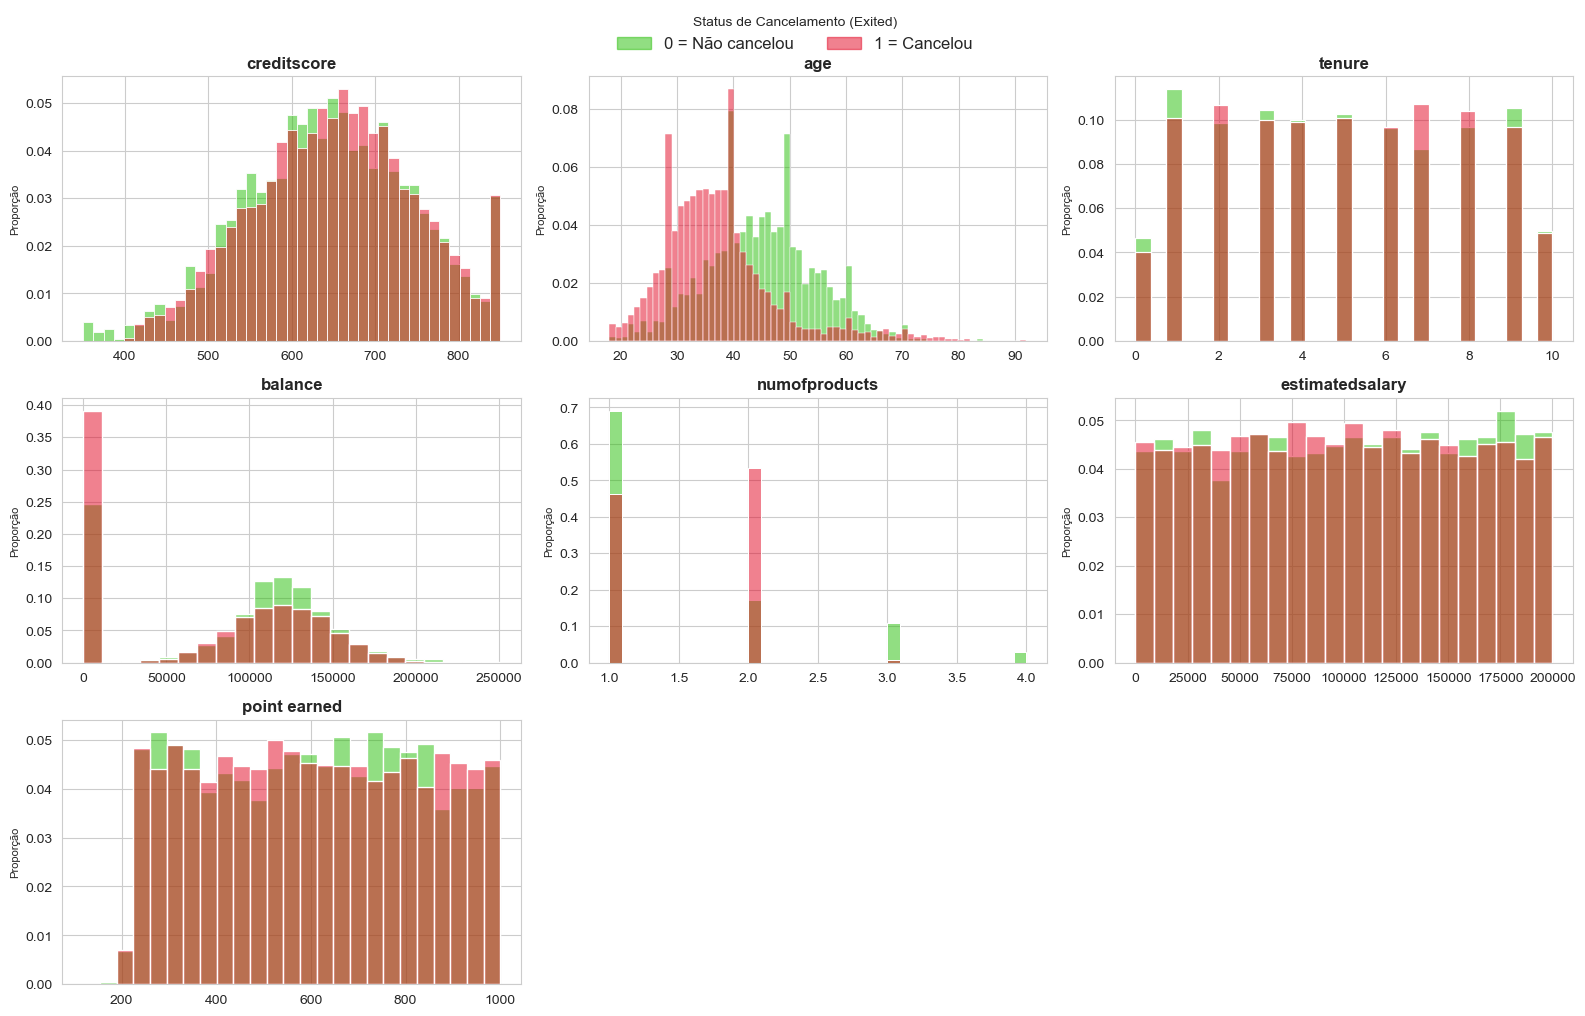

In [41]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(va_num):
    sns.histplot(
        data=df,
        x=col,
        hue='exited',
        stat='proportion',
        common_norm=False,
        kde=False,
        palette=["#E20421", "#25BE06"],
        alpha=0.5,
        ax=axes[i],
        legend=False
    )

    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Proporção', fontsize=8)

for j in range(len(va_num), len(axes)):
    fig.delaxes(axes[j])

patch_0 = mpatches.Patch(color = "#25BE06", label='0 = Não cancelou', alpha=0.5)
patch_1 = mpatches.Patch(color = "#E20421", label='1 = Cancelou', alpha=0.5)

fig.legend(handles=[patch_0, patch_1], 
           loc='upper center', 
           bbox_to_anchor=(0.5, 1.02), 
           ncol=2, 
           fontsize=12, 
           title='Status de Cancelamento (Exited)', 
           title_fontsize=10,
           frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.98])

plt.show()

O cruzamento visual das variáveis numéricas com a variável alvo **exited** revelou as principais motivos da evasão na nossa base. A idade **age** provou ser um fator determinante, a lealdade é forte entre os jovens, mas o risco de churn dispara expressivamente para clientes acima dos 45 anos. O engajamento com os serviços **numofproducts** também demonstrou um padrão claro, clientes com 2 produtos são os mais fiéis, enquanto possuir apenas 1 produto ou mais de 3 é um forte indicativo de cancelamento. Variáveis contínuas como **estimatedsalary**, **creditscore**, **tenure** e **point earned** apresentaram distribuições idênticas para ambas as classes, provando não ter influência sobre a retenção. Essa descoberta direciona a modelagem preditiva a focar na idade e no número de produtos adquiridos como suas principais estratégias.

### <b> Boxplot das variáveis numéricas levando em consideração a variável exited</b>

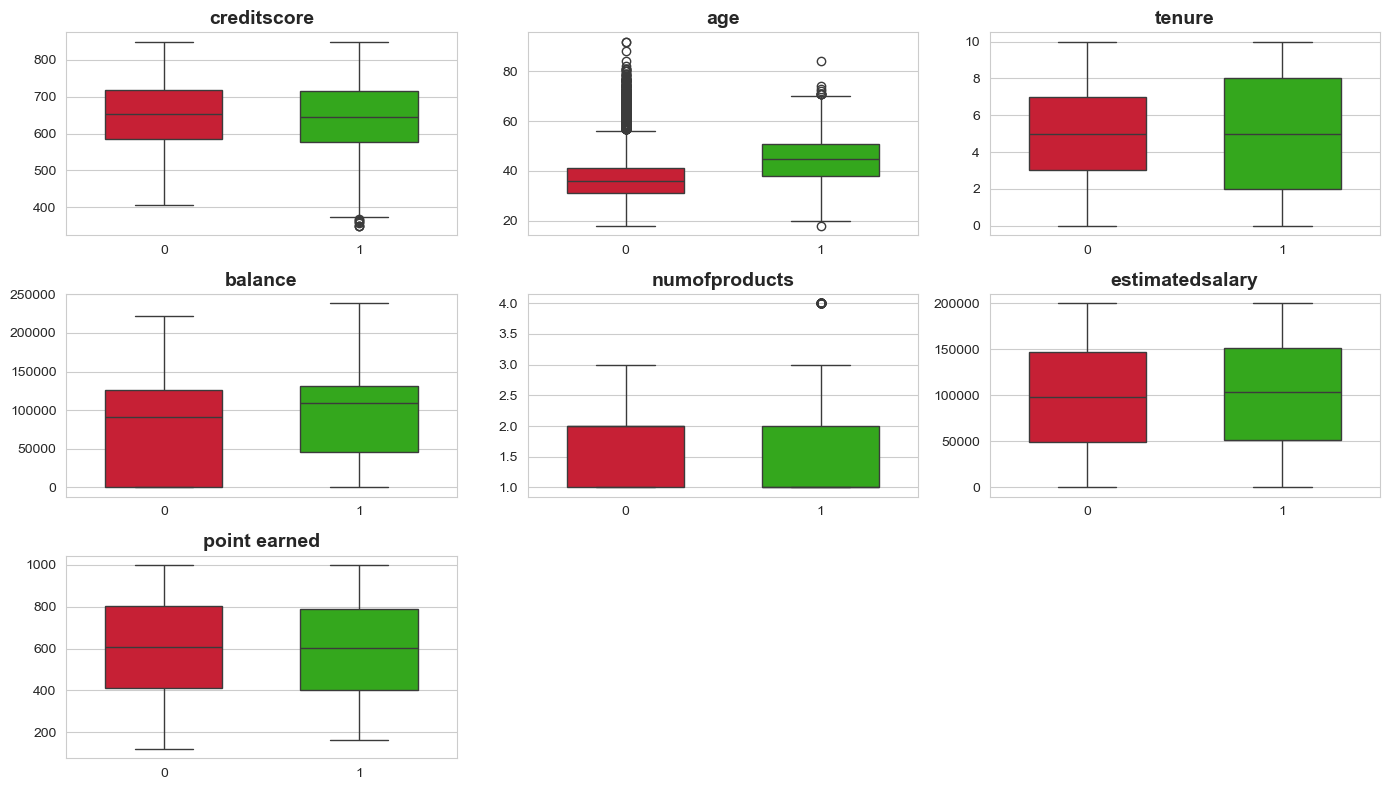

In [33]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(14, 8))

axes = axes.flatten()

for i, var in enumerate(va_num):

    sns.boxplot(
        data=treino,
        x='exited',        
        y=var,             
        hue='exited',      
        palette= ["#E20421", "#25BE06"],
        ax=axes[i],
        width=0.6,         
        legend=False       
    )

    axes[i].set_title(var, fontsize=14, fontweight='bold')

    axes[i].set_ylabel('')
    axes[i].set_xlabel('') 

for j in range(len(va_num), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.show()

A comparação por boxplots bivariados consolida matematicamente as hipóteses levantadas anteriormente. Fica evidente a forte separação na variável **age**, onde a mediana dos clientes que cancelam se estabelece em um patamar superior aproximadamente 45 anos em comparação aos retidos aproximadamente 37 anos. O saldo bancário **balance** também apresenta um sutil deslocamento de quartis, evidenciando que clientes retidos têm maior incidência de saldos zerados ou muito baixos. Por outro lado, o alinhamento quase perfeito das caixas em **estimatedsalary**, **creditscore**, **tenure** e **point earned** reforça a ausência de correlação dessas métricas com o churn. Esses resultados confirmam quais features carregam o sinal preditivo e quais apenas adicionam ruído ao conjunto de dados.

### <b> Boxplot das variáveis numéricas considerando apenas cliente que cancelaram o contrato</b>

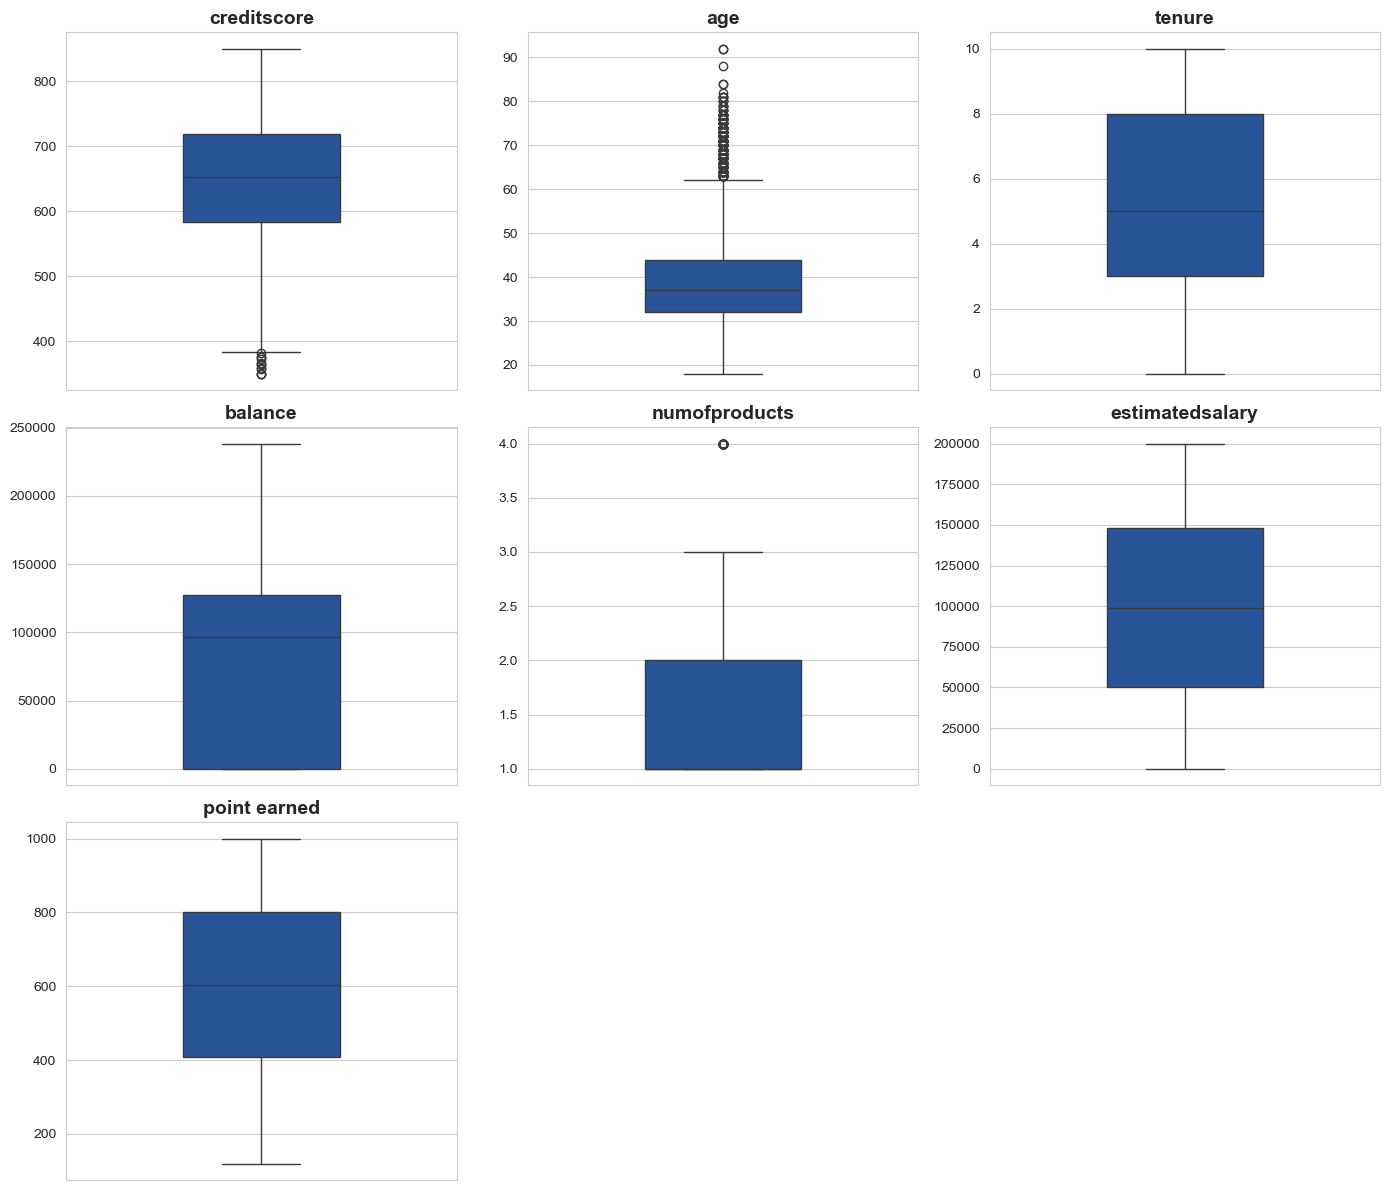

In [34]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(14, 12))

axes = axes.flatten()

for i, var in enumerate(va_num):

    sns.boxplot(
        y=treino[var],
        ax=axes[i],
        color="#1652aaff",
        width=0.4
    )

    axes[i].set_title(
        var,
        fontsize=14,
        fontweight='bold'
    )

    axes[i].set_ylabel('')

    axes[i].set_xticks([])

for j in range(len(va_num), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.show()

O isolamento do perfil dos clientes que cancelaram o contrato revela que o banco está perdendo um público maduro e com capital. A análise dos boxplots demonstra que a idade **age** mediana desse grupo salta para a faixa dos 45 anos e diferentemente da base retida, o primeiro quartil de saldo **balance** afasta-se do zero, concentrando-se acima de 50 mil. Outro traço marcante é o baixo consumo de portfólio, com a maioria dos evadidos concentrada em apenas 1 produto bancário **numofproducts**. As demais variáveis contínuas **estimatedsalary**, **creditscore**, **point earned** e **tenure** apresentam distribuições amplas e sem concentrações específicas, demonstrando que o cliente que abandona o banco pertence a todas as faixas de renda e níveis de pontuação, sendo a sua saída motivada muito mais pela idade e pela falta de diversificação de produtos.

### <b> Gráficos de barras das variáveis categóricas considerando apenas cliente que cancelaram o contrato</b>

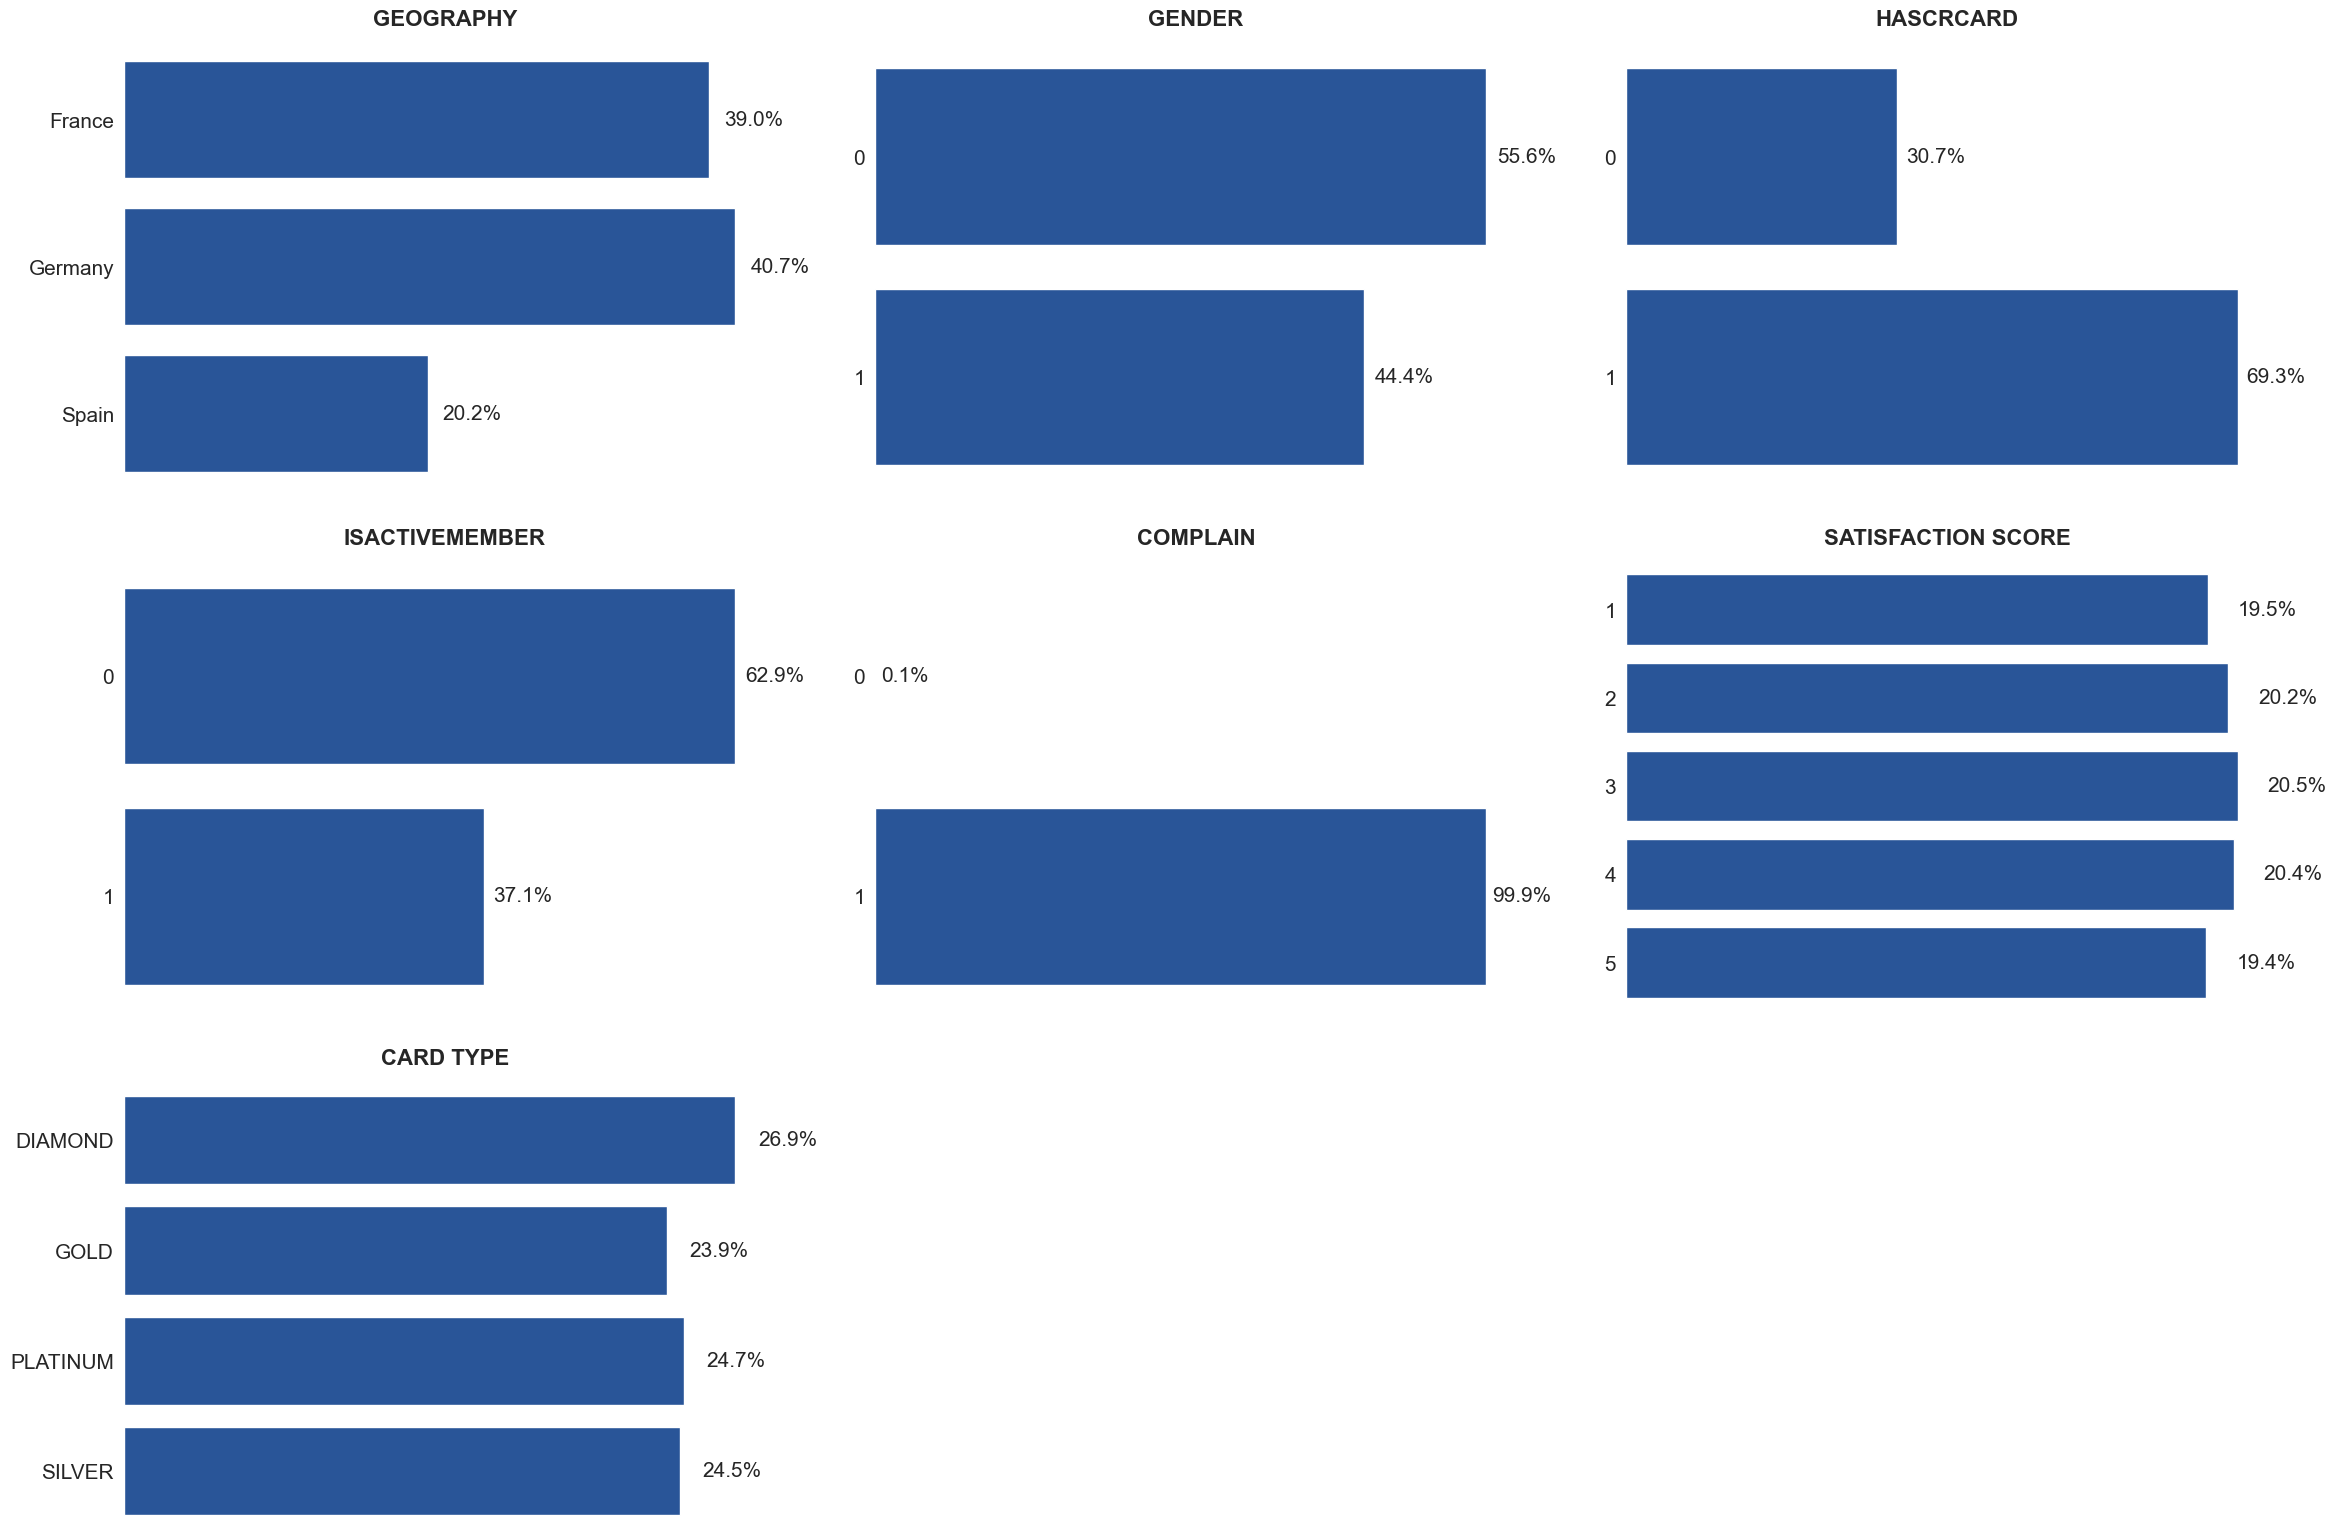

In [35]:
treino_churners = treino[treino['exited'] == 1]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(24, 16))
axes = axes.flatten() 

for i, var in enumerate(va_cat):
    proporcoes = treino_churners[var].value_counts(normalize=True).sort_index() * 100
    rotulos_y = proporcoes.index.astype(str)

    sns.barplot(x=proporcoes.values, y=rotulos_y, ax=axes[i], color="#1652aaff")

    axes[i].set_title(var.upper(), fontsize=16, fontweight='bold', pad=15) 

    axes[i].tick_params(axis='y', labelsize=15) 

    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].set_xticks([])
    sns.despine(ax=axes[i], left=True, bottom=True)

    for p in axes[i].patches:
        width = p.get_width()
        axes[i].text(width + 1, 
                     p.get_y() + p.get_height() / 2, 
                     f'{width:.1f}%', 
                     ha='left', 
                     va='center', 
                     fontsize=15)

for j in range(len(va_cat), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=3.0)
plt.show()

O cruzamento das variáveis categóricas revela diretrizes cruciais para a modelagem. Geograficamente, a Alemanha apresenta um risco de evasão desproporcionalmente alto, e a inatividade confirma-se como um forte impulsionador de cancelamentos. Variáveis como **hascrcard**, **satisfaction score** e **card type** exibiram proporções idênticas em ambas as classes, provando sua total irrelevância preditiva. O achado mais sensível, contudo, reside na variável **complain**, que demonstra uma separação de classes quase perfeita. Essa correlação extrema sugere um caso clássico de vazamento de dados, indicando que o registro da reclamação ocorre essencialmente no mesmo momento do cancelamento, o que exigirá a remoção dessa feature para garantir a generalização do modelo preditivo.

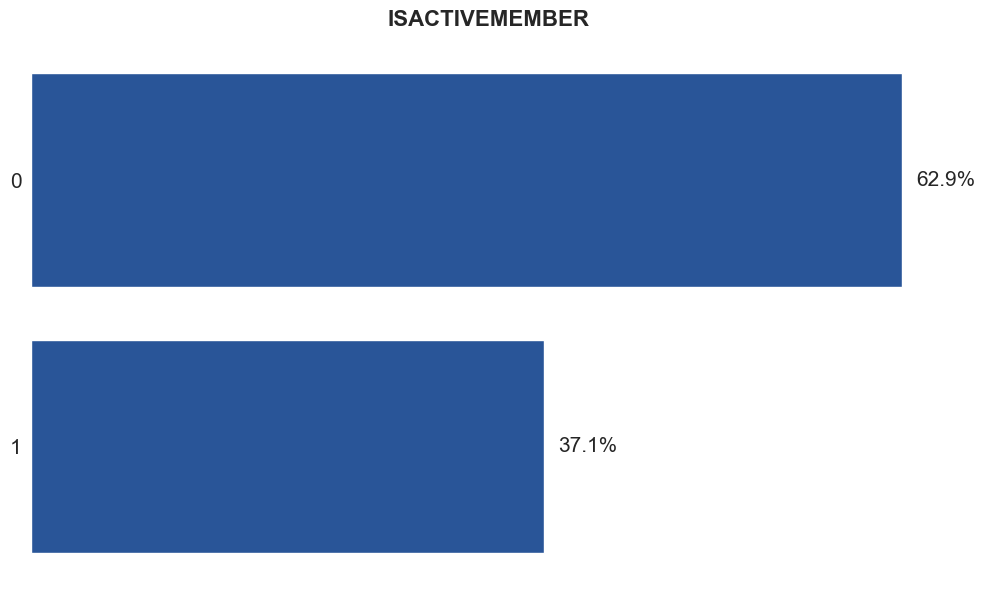

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrando apenas os clientes que cancelaram (churn)
treino_churners = treino[treino['exited'] == 1]

# Criação de uma única figura e eixo
fig, ax = plt.subplots(figsize=(10, 6))

# Definindo a variável alvo
var = 'isactivemember' # Verifique se na sua base está escrito assim mesmo ou com letras maiúsculas

# Calculando as proporções apenas para o grupo de churn
proporcoes = treino_churners[var].value_counts(normalize=True).sort_index() * 100
rotulos_y = proporcoes.index.astype(str)

# Criando o gráfico de barras horizontal
sns.barplot(x=proporcoes.values, y=rotulos_y, ax=ax, color="#1652aaff")

# Estilizando o gráfico para manter sua identidade visual
ax.set_title(var.upper(), fontsize=16, fontweight='bold', pad=15)
ax.tick_params(axis='y', labelsize=15)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([]) # Remove os números do eixo X inferior

# Removendo bordas para um visual limpo
sns.despine(ax=ax, left=True, bottom=True)

# Adicionando os rótulos de dados (porcentagens) nas barras
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 1, 
            p.get_y() + p.get_height() / 2, 
            f'{width:.1f}%', 
            ha='left', 
            va='center', 
            fontsize=15)

# Ajuste de layout
plt.tight_layout()

# Salva a imagem em alta resolução antes de exibir
plt.savefig('grafico_churners_isactivemember.png', format='png', dpi=300, bbox_inches='tight')

# Exibe o gráfico
plt.show()

### <b> Matriz de correlação</b>

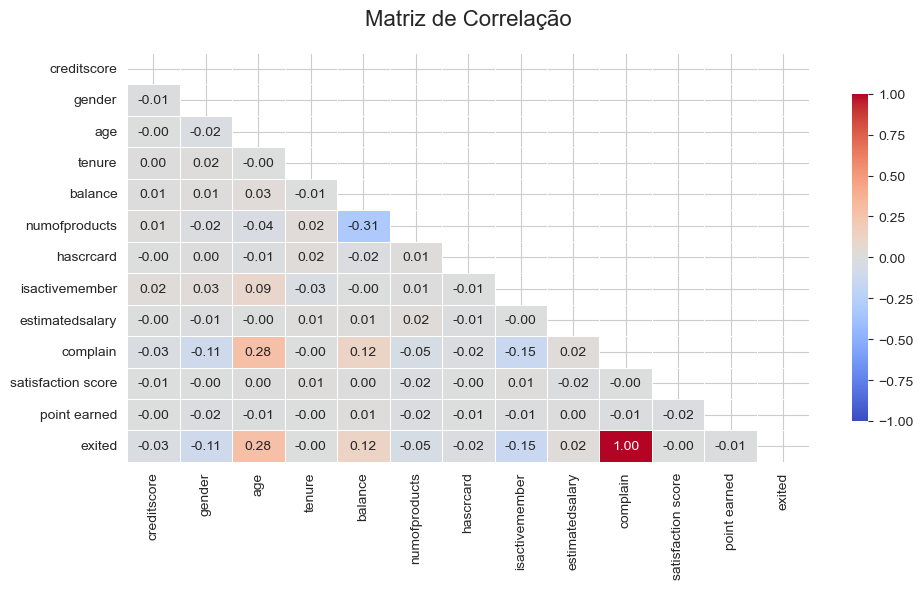

In [ ]:
corr_matrix = treino.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 6))

sns.heatmap(
    corr_matrix, 
    mask=mask,               
    annot=True,              
    fmt=".2f",               
    cmap="coolwarm",         
    vmin=-1,                 
    vmax=1,                  
    linewidths=0.5,          
    cbar_kws={"shrink": .8}  
)

plt.title('Matriz de Correlação', fontsize=16, pad=20)

plt.tight_layout()

plt.show()

A matriz de correlação chancela as descobertas visuais anteriores e define os rumos da modelagem. A correlação absoluta 1.0 entre **complain** e **exited** comprova o cenário de vazamento de dados, exigindo a remoção sumária dessa feature para evitar o enviesamento do algoritmo. Livre desse ruído, os principais preditores matemáticos do churn são a idade **age** e a inatividade da conta **isactivemember**. Positivamente, o mapa de calor revela a ausência de multicolinearidade severa entre as variáveis independentes, atestando que características como **creditscore**, **estimatedsalary** e **tenure**, não geram sobreposição de dados, embora sua baixa correlação com o alvo também sugira um fraco poder discriminatório para o modelo final.